In [1]:
import numpy as np
import pandas as pd
import seaborn as sb
import matplotlib.pyplot as plt
%matplotlib widget
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import _cm
plt.rcParams['figure.figsize'] = (16, 9)
plt.style.use('ggplot')
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score

In [2]:
data =pd.read_csv('articulos_ml.csv')
data.shape

(161, 8)

In [3]:
data.head()

,Title,url,Word count,# of Links,# of comments,# Images video,Elapsed days,# Shares
0,What is Machine Learning and how do we use it ...,https://blog.signals.network/what-is-machine-l...,1888,1,2.0,2,34,200000
1,10 Companies Using Machine Learning in Cool Ways,NaN,1742,9,NaN,9,5,25000
2,How Artificial Intelligence Is Revolutionizing...,NaN,962,6,0.0,1,10,42000
3,Dbrain and the Blockchain of Artificial Intell...,NaN,1221,3,NaN,2,68,200000
4,Nasa finds entire solar system filled with eig...,NaN,2039,1,104.0,4,131,200000


In [4]:
data.describe()

,Word count,# of Links,# of comments,# Images video,Elapsed days,# Shares
count,161.000000,161.000000,129.000000,161.000000,161.000000,161.000000
mean,1808.260870,9.739130,8.782946,3.670807,98.124224,27948.347826
std,1141.919385,47.271625,13.142822,3.418290,114.337535,43408.006839
min,250.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,990.000000,3.000000,2.000000,1.000000,31.000000,2800.000000
50%,1674.000000,5.000000,6.000000,3.000000,62.000000,16458.000000
75%,2369.000000,7.000000,12.000000,5.000000,124.000000,35691.000000
max,8401.000000,600.000000,104.000000,22.000000,1002.000000,350000.000000


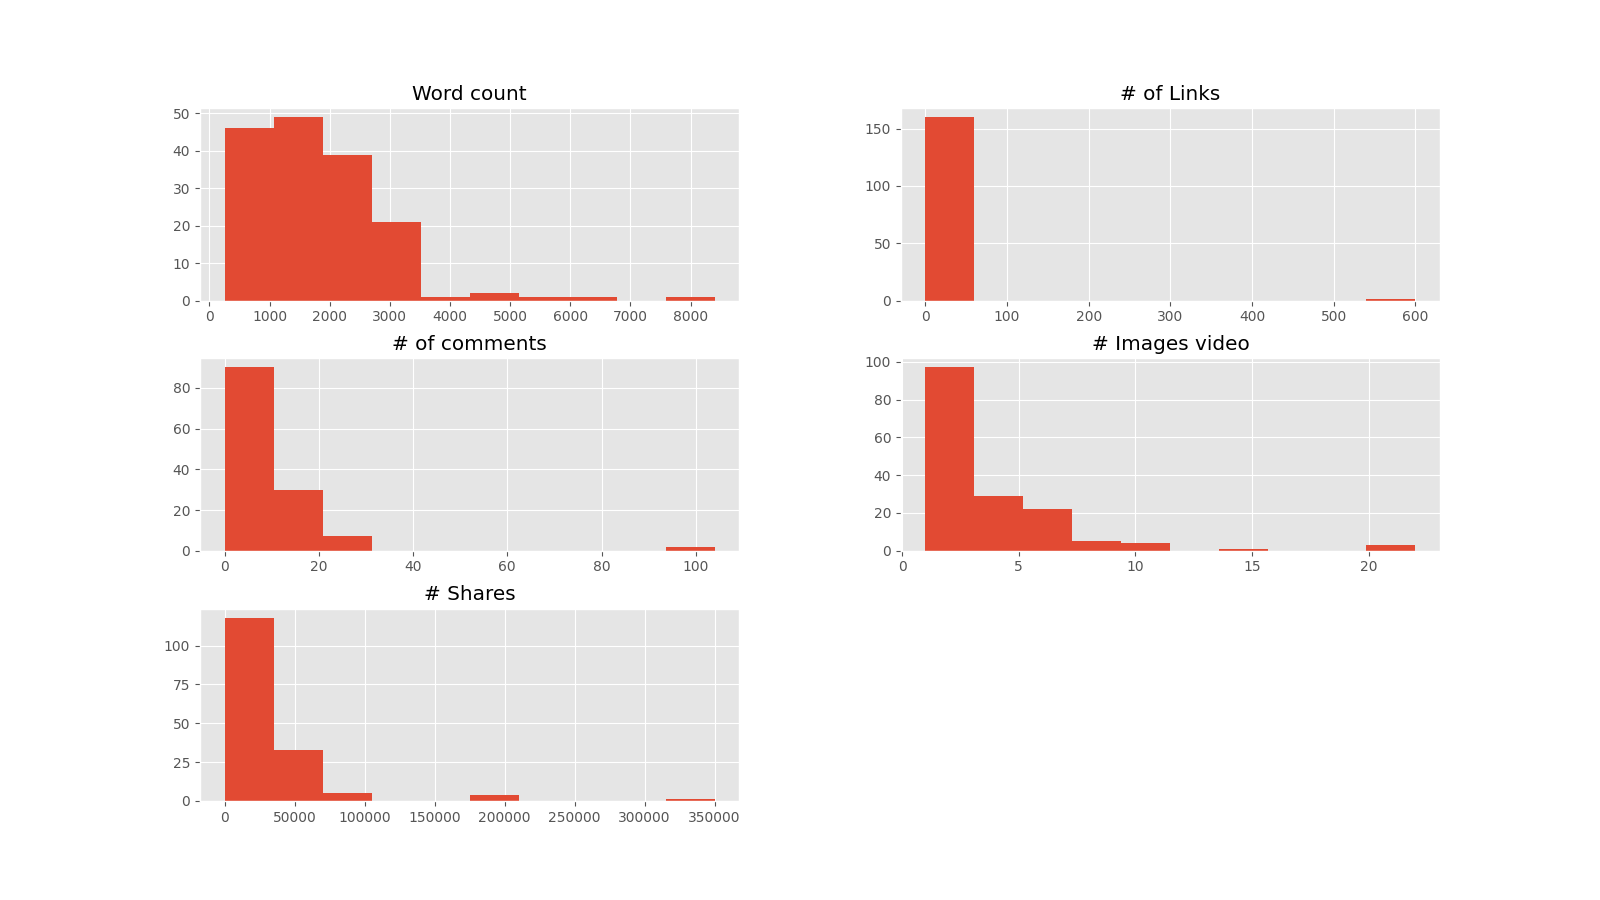

In [5]:
data.drop(['Title', 'url', 'Elapsed days'], axis = 1).hist()
plt.show()

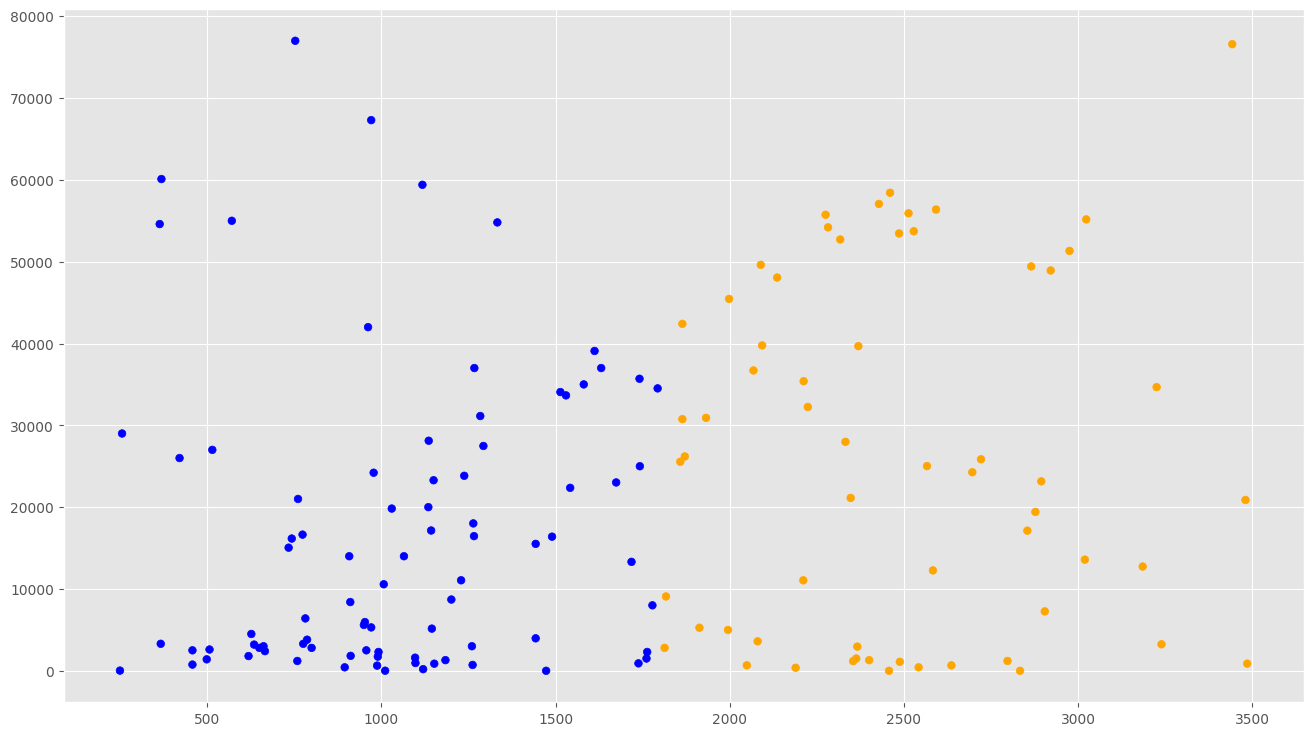

In [ ]:
filtered_data = data[(data['Word count'] <= 3500) & (data['# Shares'] <= 80000)]

colores = ['orange', 'blue']
tamanios = [30,60]

f1 = filtered_data['Word count'].values
f2 = filtered_data['# Shares'].values

asignar = []
for index, row in filtered_data.iterrows():
    if(row['Word count'] > 1808):
        asignar.append(colores[0])
    else:
        asignar.append(colores[1])

plt.scatter(f1, f2, c=asignar, s=tamanios[0])
plt.show()
    

In [ ]:
# Asignamos nuestra variable de entrada X para entrenamiento y las etiquetas Y.
dataX = filtered_data[['Word count']]
X_train = np.array(dataX)
y_train = filtered_data['# Shares'].values

# Creamos el objeto de regresion linear
regr = linear_model.LinearRegression()

# Entrenamos nuestro modelo
regr.fit(X_train, y_train)


# hacemos las predicciones que en definitiva una linea( en este caso, al ser 2D)
y_pred = regr.predict(X_train)

# Veamos los coeficientes obtenidos, en nuestro caso, sera la tangente
print('Coeffcients: \n', regr.coef_)

# Este es el valor donde corta el eje Y(en X = 0)
print('Independent term: \n', regr.intercept_)

#Error Cuadrado medio
print("Mean squared error: %.2f" % mean_squared_error(y_train, y_pred))

#Puntuaje de Varianza. El mejor es un 1.0
print('Variance score: %.2f' % r2_score(y_train, y_pred))


Coeffcients: 
 [5.69765366]
Independent term: 
 11200.303223074157
Mean squared error: 372888728.34
Variance score: 0.06


In [ ]:
y_Dosmil = regr.predict([[2000]])
print(y_Dosmil)

[22595.61053785]


In [ ]:
# Vamos a intenetar mejorar el Modelo, con una dimension mas
suma = (filtered_data['# of Links'] + filtered_data['# of comments'].fillna(0) + filtered_data['# Images video'])

dataX2 = pd.DataFrame()
dataX2['Word count'] = filtered_data['Word count']
dataX2['suma'] = suma
XY_train = np.array(dataX2)
z_train = filtered_data['# Shares'].values


In [ ]:
# Creamos un nuevo objeto de Regresion Lineal
regr2 = linear_model.LinearRegression()

# Entrenamos el modelo, esta vez, con 2 dimensiones
# obtendremos 2 coeficientes, para graficar un plano
regr2.fit(XY_train, z_train)

# Hacemos la prediccion con la que tendremos puntos sobre el plano hallado
z_pred = regr2.predict(XY_train)

# Los coeficientes
print('Coefficients: \n', regr2.coef_)

#Error cuadratico medio
print('Mean squared error: %.2f' % mean_squared_error(z_train, z_pred))

# Evaluamos el puntaje de varianza(siendo 1.0 el mejor posible)
print('Variance score: %.2f' % r2_score(z_train, z_pred))



Coefficients: 
 [   6.63216324 -483.40753769]
Mean squared error: 352122816.48
Variance score: 0.11


In [ ]:
fig = plt.figure()
ax = Axes3D(fig)

#creamos una malla donde haremos el plano
xx, yy = np.meshgrid(np.linspace(0, 3500, num=10), np.linspace(0, 60, num=10))

#calculamos los valores del plano para los puntos x e y
nuevoX = (regr2.coef_[0] * xx)
nuevoY = (regr2.coef_[1] * yy)

# calculamos los valores de z. Debemos sumar el pto de intercepcion
z = (nuevoX + nuevoY + regr2.intercept_)

# graficamos el plano
ax.plot_surface(xx, yy, z, alpha = 0.2, cmap = 'hot')

# graficamos en azul los puntos en 3D
ax.scatter(XY_train[:, 0], XY_train[:, 1], z_train, c = 'blue', s=30)

# graficamos en rojo los puntos que predecimos
ax.scatter(XY_train[:, 0], XY_train[:, 1], z_pred, c = 'red', s=40)

# con esto situamos la camara con la que visualizamos

ax.view_init(elev=30, azim=65)
ax.set_xlabel('Cantidad de Palabras')
ax.set_ylabel('Cantidad de enlaces, comentarios e imagenes')
ax.set_zlabel('Compartido en redes')
ax.set_title('Regresion lineal con multiple variables')

plt.show()

<Figure size 1600x900 with 0 Axes>